This project analyzes a taxi trip dataset to uncover insights about demand patterns, traffic behavior, revenue distribution, and urban mobility trends. Using Python-based data analytics techniques, the study explores how taxi demand varies across time, location, and trip characteristics.

The project applies data cleaning, feature engineering, exploratory data analysis (EDA), and advanced visualizations to generate actionable insights that could help taxi companies optimize driver allocation, pricing strategies, and operational efficiency.


In [1]:
#import libaries 
import pandas as pd 
import numpy as np 


In [2]:
#load the data set 
df = pd.read_csv("taxi1.csv")
                 

In [3]:
df

,trip_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,fare,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon
0,1adedef3b9733f6a1859137ce37d8c685ad36cea,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,121.0,0.45,4.25,41.899602,NaN,41.899602,NaN
1,45b165d46f064d1c685e5fa0ff222437970114f8,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,2.0,0.00,20.00,41.885281,-87.657233,41.885281,-87.657233
2,c23cbb41a952defb103a40ca767a32c387532614,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,1163.0,4.50,16.25,41.899602,-87.633308,41.944227,-87.655998
3,cde7d22932829a7b19fb43bfd9a1d635c1e3f04e,2023-12-31T23:45:00.000,2024-01-01T00:15:00.000,1852.0,22.97,55.50,41.979071,-87.903040,NaN,NaN
4,f40c2cda1cea33c2265a34b2ce1eb454067ad8d2,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,0.0,0.00,3.25,41.901207,-87.676356,NaN,-87.676356
...,...,...,...,...,...,...,...,...,...,...
7395,6dc433f004d87f9a71d3f519bca6efb7932ac20d,2023-12-31T20:30:00.000,2023-12-31T20:30:00.000,286.0,0.40,5.00,41.892073,-87.628874,41.884987,NaN
7396,822fd16ec17d3ba378471ec451f595e2503cf9e3,2023-12-31T14:00:00.000,2023-12-31T14:15:00.000,660.0,1.40,8.25,41.878866,-87.625192,41.899602,-87.633308
7397,c13c05b273ac93cb84bc911132bf8bbc75290e72,2023-12-31T18:45:00.000,2023-12-31T18:45:00.000,62.0,0.05,20.00,41.884987,NaN,41.880994,-87.632746
7398,a6630e284573892bbafeae2ab3f2de27b18e4988,2023-12-31T23:15:00.000,2023-12-31T23:45:00.000,1267.0,13.36,34.00,41.792592,-87.769615,41.922686,-87.649489


In [4]:
#Rename columnz 

df = df.rename(columns={
    "trip_start_timestamp":"start_ts",
    "trip_end_timestamp":"end_ts",
    "trip_seconds":"trp_sec",
    "trip_miles":"trp_mi",
    "pickup_lat":"p_lat",
    "pickup_lon":"p_lon",
    "dropoff_lat":"d_lat",
    "dropoff_lon":"d_lon"
})


In [5]:
 df.replace('', np.nan, inplace=True)
#  converting empty values to null 

IndentationError: unexpected indent (338492626.py, line 1)

In [7]:
import pandas as pd
import numpy as np

# convert empty strings to NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# check null values
print(df.isnull().sum())

trip_id        0
start_ts       0
end_ts         0
trp_sec      582
trp_mi       525
fare         596
p_lat        716
p_lon       1089
d_lat       1559
d_lon       1484
dtype: int64


In [8]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon
0,1adedef3b9733f6a1859137ce37d8c685ad36cea,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,121.0,0.45,4.25,41.899602,NaN,41.899602,NaN
1,45b165d46f064d1c685e5fa0ff222437970114f8,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,2.0,0.00,20.00,41.885281,-87.657233,41.885281,-87.657233
2,c23cbb41a952defb103a40ca767a32c387532614,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,1163.0,4.50,16.25,41.899602,-87.633308,41.944227,-87.655998
3,cde7d22932829a7b19fb43bfd9a1d635c1e3f04e,2023-12-31T23:45:00.000,2024-01-01T00:15:00.000,1852.0,22.97,55.50,41.979071,-87.903040,NaN,NaN
4,f40c2cda1cea33c2265a34b2ce1eb454067ad8d2,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,0.0,0.00,3.25,41.901207,-87.676356,NaN,-87.676356
...,...,...,...,...,...,...,...,...,...,...
7395,6dc433f004d87f9a71d3f519bca6efb7932ac20d,2023-12-31T20:30:00.000,2023-12-31T20:30:00.000,286.0,0.40,5.00,41.892073,-87.628874,41.884987,NaN
7396,822fd16ec17d3ba378471ec451f595e2503cf9e3,2023-12-31T14:00:00.000,2023-12-31T14:15:00.000,660.0,1.40,8.25,41.878866,-87.625192,41.899602,-87.633308
7397,c13c05b273ac93cb84bc911132bf8bbc75290e72,2023-12-31T18:45:00.000,2023-12-31T18:45:00.000,62.0,0.05,20.00,41.884987,NaN,41.880994,-87.632746
7398,a6630e284573892bbafeae2ab3f2de27b18e4988,2023-12-31T23:15:00.000,2023-12-31T23:45:00.000,1267.0,13.36,34.00,41.792592,-87.769615,41.922686,-87.649489


TypeError: Could not convert ['...'
 '2023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00.0002023-12-31T23:45:00

In [11]:
#check missing values 
print(df.isnull().sum())

trip_id        0
start_ts       0
end_ts         0
trp_sec      582
trp_mi       525
fare         596
p_lat        716
p_lon       1089
d_lat       1559
d_lon       1484
dtype: int64


In [12]:
#replace missing values 
df["trp_sec"].fillna(df["trp_sec"].mean(), inplace=True) 
df["trp_mi"].fillna(df["trp_mi"].mean(), inplace=True) 
df["fare"].fillna(df["fare"].mean(), inplace=True) 
df["p_lat"].fillna(0, inplace=True)
df["p_lon"].fillna(0, inplace=True)
df["d_lat"].fillna(0, inplace=True)
df["d_lon"].fillna(0, inplace=True)

/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_53390/2220352675.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["trp_sec"].fillna(df["trp_sec"].mean(), inplace=True)
/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_53390/2220352675.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

In [13]:
# check where nan values exist 
print(df.isna().sum())


trip_id     0
start_ts    0
end_ts      0
trp_sec     0
trp_mi      0
fare        0
p_lat       0
p_lon       0
d_lat       0
d_lon       0
dtype: int64


In [14]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon
0,1adedef3b9733f6a1859137ce37d8c685ad36cea,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,121.0,0.45,4.25,41.899602,0.000000,41.899602,0.000000
1,45b165d46f064d1c685e5fa0ff222437970114f8,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,2.0,0.00,20.00,41.885281,-87.657233,41.885281,-87.657233
2,c23cbb41a952defb103a40ca767a32c387532614,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,1163.0,4.50,16.25,41.899602,-87.633308,41.944227,-87.655998
3,cde7d22932829a7b19fb43bfd9a1d635c1e3f04e,2023-12-31T23:45:00.000,2024-01-01T00:15:00.000,1852.0,22.97,55.50,41.979071,-87.903040,0.000000,0.000000
4,f40c2cda1cea33c2265a34b2ce1eb454067ad8d2,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,0.0,0.00,3.25,41.901207,-87.676356,0.000000,-87.676356
...,...,...,...,...,...,...,...,...,...,...
7395,6dc433f004d87f9a71d3f519bca6efb7932ac20d,2023-12-31T20:30:00.000,2023-12-31T20:30:00.000,286.0,0.40,5.00,41.892073,-87.628874,41.884987,0.000000
7396,822fd16ec17d3ba378471ec451f595e2503cf9e3,2023-12-31T14:00:00.000,2023-12-31T14:15:00.000,660.0,1.40,8.25,41.878866,-87.625192,41.899602,-87.633308
7397,c13c05b273ac93cb84bc911132bf8bbc75290e72,2023-12-31T18:45:00.000,2023-12-31T18:45:00.000,62.0,0.05,20.00,41.884987,0.000000,41.880994,-87.632746
7398,a6630e284573892bbafeae2ab3f2de27b18e4988,2023-12-31T23:15:00.000,2023-12-31T23:45:00.000,1267.0,13.36,34.00,41.792592,-87.769615,41.922686,-87.649489


In [15]:
# remove negative or zero trip location 
#taxi trips cannot have 0 or negative time 
df = df[df["trp_sec"] > 0]
print((df["trp_sec"] <= 0).sum())


0


In [16]:
#remove negative or zero trip location 
#trips must have positive miles 
df = df[df["trp_mi"]>0]
print((df["trp_mi"] <= 0).sum())

0


In [17]:
#remove invalid fare values 

df = df[df["fare"] > 0]

In [18]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon
0,1adedef3b9733f6a1859137ce37d8c685ad36cea,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,121.0,0.45,4.25,41.899602,0.000000,41.899602,0.000000
2,c23cbb41a952defb103a40ca767a32c387532614,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,1163.0,4.50,16.25,41.899602,-87.633308,41.944227,-87.655998
3,cde7d22932829a7b19fb43bfd9a1d635c1e3f04e,2023-12-31T23:45:00.000,2024-01-01T00:15:00.000,1852.0,22.97,55.50,41.979071,-87.903040,0.000000,0.000000
5,c6cb3aad561e0c407239333d535a4922540f9adc,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,839.0,7.17,19.75,41.980264,-87.913625,41.985015,0.000000
6,74ec66e70210fee0078aa53cb2f90c2282fca498,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,284.0,0.30,9.00,41.899602,-87.633308,41.899602,-87.633308
...,...,...,...,...,...,...,...,...,...,...
7395,6dc433f004d87f9a71d3f519bca6efb7932ac20d,2023-12-31T20:30:00.000,2023-12-31T20:30:00.000,286.0,0.40,5.00,41.892073,-87.628874,41.884987,0.000000
7396,822fd16ec17d3ba378471ec451f595e2503cf9e3,2023-12-31T14:00:00.000,2023-12-31T14:15:00.000,660.0,1.40,8.25,41.878866,-87.625192,41.899602,-87.633308
7397,c13c05b273ac93cb84bc911132bf8bbc75290e72,2023-12-31T18:45:00.000,2023-12-31T18:45:00.000,62.0,0.05,20.00,41.884987,0.000000,41.880994,-87.632746
7398,a6630e284573892bbafeae2ab3f2de27b18e4988,2023-12-31T23:15:00.000,2023-12-31T23:45:00.000,1267.0,13.36,34.00,41.792592,-87.769615,41.922686,-87.649489


In [19]:
#Remove Duplicate Trip IDs
df = df.sort_values("start_ts")
df = df.drop_duplicates(subset="trip_id", keep="first")

In [20]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon
6920,f2565bcb00e80bc5401938c2c4c26df35362841b,2023-12-31T13:15:00.000,2023-12-31T13:45:00.000,2115.0,19.23,55.140000,41.717493,-87.648895,41.890609,-87.756047
6931,42b771b10274b9006ff98b20b759811c4d519a8d,2023-12-31T13:15:00.000,2023-12-31T13:30:00.000,900.0,0.30,18.250000,41.790506,0.000000,41.859350,-87.617358
6932,ed5ae48c8d792adb72a8c3095f3a1706d701fa27,2023-12-31T13:15:00.000,2023-12-31T13:15:00.000,375.0,0.72,90.025745,41.899602,-87.633308,41.899602,-87.633308
6934,e486ac85b51061fab97435d3ccd2fe02c23a2545,2023-12-31T13:15:00.000,2023-12-31T13:30:00.000,1124.0,10.28,27.250000,41.899602,-87.633308,41.794090,-87.592311
6936,1c20b1064056fabc88b37c05b0232a723c4f8f65,2023-12-31T13:15:00.000,2023-12-31T13:45:00.000,1620.0,0.90,38.250000,999.000000,-87.642498,41.944227,-87.655998
...,...,...,...,...,...,...,...,...,...,...
52,f3a139c0df3513324ff3f699bf40db2e84291e3a,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,1228.0,4.29,15.250000,999.000000,-87.655998,41.938666,-87.711211
55,b68a7310d2ba573ce09f55fa546408264e0b3dd7,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,755.0,2.37,90.025745,41.885281,-87.657233,41.899156,-87.626211
56,9a487d97cd444f768065617fb0d7b0f10b602dca,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,518.0,1.34,9.000000,41.944227,-87.655998,41.944227,-87.655998
43,c3807aafaf2272b30efbec3595a7b192a92f632d,2023-12-31T23:45:00.000,2024-01-01T00:30:00.000,2295.0,5.53,21.500000,41.874005,-87.663518,41.878866,-87.625192


In [21]:
#Fix Negative Trip Duration
avg_sec = df[df["trp_sec"] > 0]["trp_sec"].mean()

df.loc[df["trp_sec"] < 0, "trp_sec"] = avg_sec

In [22]:
#Convert Timestamp Columns
df["start_ts"] = pd.to_datetime(df["start_ts"])
df["end_ts"] = pd.to_datetime(df["end_ts"])

In [23]:
#Recalculate Trip Duration
df["trp_sec"] = (df["end_ts"] - df["start_ts"]).dt.total_seconds()

In [24]:
#Remove Fake GPS Coordinates
df.loc[df["p_lat"].isin([0,999,-999]), "p_lat"] = np.nan
df.loc[df["p_lon"].isin([0,999,-999]), "p_lon"] = np.nan
df.loc[df["d_lat"].isin([0,999,-999]), "d_lat"] = np.nan
df.loc[df["d_lon"].isin([0,999,-999]), "d_lon"] = np.nan

In [25]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon
6920,f2565bcb00e80bc5401938c2c4c26df35362841b,2023-12-31 13:15:00,2023-12-31 13:45:00,1800.0,19.23,55.140000,41.717493,-87.648895,41.890609,-87.756047
6931,42b771b10274b9006ff98b20b759811c4d519a8d,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,0.30,18.250000,41.790506,NaN,41.859350,-87.617358
6932,ed5ae48c8d792adb72a8c3095f3a1706d701fa27,2023-12-31 13:15:00,2023-12-31 13:15:00,0.0,0.72,90.025745,41.899602,-87.633308,41.899602,-87.633308
6934,e486ac85b51061fab97435d3ccd2fe02c23a2545,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,10.28,27.250000,41.899602,-87.633308,41.794090,-87.592311
6936,1c20b1064056fabc88b37c05b0232a723c4f8f65,2023-12-31 13:15:00,2023-12-31 13:45:00,1800.0,0.90,38.250000,NaN,-87.642498,41.944227,-87.655998
...,...,...,...,...,...,...,...,...,...,...
52,f3a139c0df3513324ff3f699bf40db2e84291e3a,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,4.29,15.250000,NaN,-87.655998,41.938666,-87.711211
55,b68a7310d2ba573ce09f55fa546408264e0b3dd7,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,2.37,90.025745,41.885281,-87.657233,41.899156,-87.626211
56,9a487d97cd444f768065617fb0d7b0f10b602dca,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,1.34,9.000000,41.944227,-87.655998,41.944227,-87.655998
43,c3807aafaf2272b30efbec3595a7b192a92f632d,2023-12-31 23:45:00,2024-01-01 00:30:00,2700.0,5.53,21.500000,41.874005,-87.663518,41.878866,-87.625192


In [26]:
#Remove Trips With Missing Coordinates
df = df.dropna(subset=["p_lat","p_lon","d_lat","d_lon"])

In [27]:
#Fix Negative Trip Distance
avg_mi = df[df["trp_mi"] > 0]["trp_mi"].mean()

df.loc[df["trp_mi"] < 0, "trp_mi"] = avg_mi

In [28]:
#Fix Extremely High Fares
avg_fare = df[df["fare"] < 200]["fare"].mean()

df.loc[df["fare"] > 200, "fare"] = avg_fare

In [29]:
#Convert Timestamp Columns
df["start_ts"] = pd.to_datetime(df["start_ts"])
df["end_ts"] = pd.to_datetime(df["end_ts"])

/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_53390/1200663550.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["start_ts"] = pd.to_datetime(df["start_ts"])
/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_53390/1200663550.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["end_ts"] = pd.to_datetime(df["end_ts"])


In [30]:
#Recalculate Trip Duration
df["trp_sec"] = (df["end_ts"] - df["start_ts"]).dt.total_seconds()

/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_53390/3919595146.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["trp_sec"] = (df["end_ts"] - df["start_ts"]).dt.total_seconds()


In [31]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon
6920,f2565bcb00e80bc5401938c2c4c26df35362841b,2023-12-31 13:15:00,2023-12-31 13:45:00,1800.0,19.230000,55.140000,41.717493,-87.648895,41.890609,-87.756047
6932,ed5ae48c8d792adb72a8c3095f3a1706d701fa27,2023-12-31 13:15:00,2023-12-31 13:15:00,0.0,0.720000,90.025745,41.899602,-87.633308,41.899602,-87.633308
6934,e486ac85b51061fab97435d3ccd2fe02c23a2545,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,10.280000,27.250000,41.899602,-87.633308,41.794090,-87.592311
6939,149b4eec76aafb0aeea1add7c23c21df359b9b4b,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,7.789097,6.750000,41.874005,-87.663518,41.899602,-87.633308
6943,3cab8417603b4df7c35113d32910deba7931f051,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,3.580000,12.250000,41.857184,-87.620335,41.899602,-87.633308
...,...,...,...,...,...,...,...,...,...,...
47,6b1b21ca32da77c68ee5d8816194ac27d9206082,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,2.800000,13.000000,41.899602,-87.633308,41.874005,-87.663518
51,54fe3bc76d6f88ffd68f1e435693ad97c83eaeae,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,15.880000,40.000000,41.741243,-87.551428,41.900070,-87.720918
55,b68a7310d2ba573ce09f55fa546408264e0b3dd7,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,2.370000,90.025745,41.885281,-87.657233,41.899156,-87.626211
56,9a487d97cd444f768065617fb0d7b0f10b602dca,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,1.340000,9.000000,41.944227,-87.655998,41.944227,-87.655998


In [32]:
#Remove Trips With Missing Coordinates
df = df.dropna(subset=["p_lat","p_lon","d_lat","d_lon"])

In [33]:
#Fix Negative Trip Distance
avg_mi = df[df["trp_mi"] > 0]["trp_mi"].mean()

df.loc[df["trp_mi"] < 0, "trp_mi"] = avg_mi

In [34]:
#Fix Negative Trip Distance
avg_mi = df[df["trp_mi"] > 0]["trp_mi"].mean()

df.loc[df["trp_mi"] < 0, "trp_mi"] = avg_mi

In [37]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon
6920,f2565bcb00e80bc5401938c2c4c26df35362841b,2023-12-31 13:15:00,2023-12-31 13:45:00,1800.0,19.230000,55.140000,41.717493,-87.648895,41.890609,-87.756047
6934,e486ac85b51061fab97435d3ccd2fe02c23a2545,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,10.280000,27.250000,41.899602,-87.633308,41.794090,-87.592311
6939,149b4eec76aafb0aeea1add7c23c21df359b9b4b,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,7.789097,6.750000,41.874005,-87.663518,41.899602,-87.633308
6943,3cab8417603b4df7c35113d32910deba7931f051,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,3.580000,12.250000,41.857184,-87.620335,41.899602,-87.633308
6945,944cff3d352957711aabb29543b5275d13cc546d,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,1.660000,8.000000,41.878866,-87.625192,41.899602,-87.633308
...,...,...,...,...,...,...,...,...,...,...
47,6b1b21ca32da77c68ee5d8816194ac27d9206082,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,2.800000,13.000000,41.899602,-87.633308,41.874005,-87.663518
51,54fe3bc76d6f88ffd68f1e435693ad97c83eaeae,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,15.880000,40.000000,41.741243,-87.551428,41.900070,-87.720918
55,b68a7310d2ba573ce09f55fa546408264e0b3dd7,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,2.370000,90.025745,41.885281,-87.657233,41.899156,-87.626211
56,9a487d97cd444f768065617fb0d7b0f10b602dca,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,1.340000,9.000000,41.944227,-87.655998,41.944227,-87.655998


In [36]:
#Remove Trips With Same Start & End Time 
df = df[df["start_ts"] != df["end_ts"]]

In [38]:
# Calculate Taxi Speed
df["speed_mph"] = df["trp_mi"] / (df["trp_sec"] / 3600)

/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_53390/733274916.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["speed_mph"] = df["trp_mi"] / (df["trp_sec"] / 3600)


In [39]:
# Remove Unrealistic Speeds
df = df[(df["speed_mph"] < 100) & (df["speed_mph"] > 1)]

In [40]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon,speed_mph
6920,f2565bcb00e80bc5401938c2c4c26df35362841b,2023-12-31 13:15:00,2023-12-31 13:45:00,1800.0,19.230000,55.140000,41.717493,-87.648895,41.890609,-87.756047,38.460000
6934,e486ac85b51061fab97435d3ccd2fe02c23a2545,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,10.280000,27.250000,41.899602,-87.633308,41.794090,-87.592311,41.120000
6939,149b4eec76aafb0aeea1add7c23c21df359b9b4b,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,7.789097,6.750000,41.874005,-87.663518,41.899602,-87.633308,31.156387
6943,3cab8417603b4df7c35113d32910deba7931f051,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,3.580000,12.250000,41.857184,-87.620335,41.899602,-87.633308,14.320000
6945,944cff3d352957711aabb29543b5275d13cc546d,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,1.660000,8.000000,41.878866,-87.625192,41.899602,-87.633308,6.640000
...,...,...,...,...,...,...,...,...,...,...,...
47,6b1b21ca32da77c68ee5d8816194ac27d9206082,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,2.800000,13.000000,41.899602,-87.633308,41.874005,-87.663518,11.200000
51,54fe3bc76d6f88ffd68f1e435693ad97c83eaeae,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,15.880000,40.000000,41.741243,-87.551428,41.900070,-87.720918,63.520000
55,b68a7310d2ba573ce09f55fa546408264e0b3dd7,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,2.370000,90.025745,41.885281,-87.657233,41.899156,-87.626211,9.480000
56,9a487d97cd444f768065617fb0d7b0f10b602dca,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,1.340000,9.000000,41.944227,-87.655998,41.944227,-87.655998,5.360000


In [41]:
# Remove incorrect longitude values
df = df[df["p_lon"] < 0]

# Remove identical latitude/longitude
df = df[df["p_lat"] != df["p_lon"]]

# Remove unrealistic speeds
df = df[(df["speed_mph"] >= 5) & (df["speed_mph"] <= 80)]

# Remove extreme fares
df = df[df["fare"] <= 70]

In [42]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon,speed_mph
6920,f2565bcb00e80bc5401938c2c4c26df35362841b,2023-12-31 13:15:00,2023-12-31 13:45:00,1800.0,19.230000,55.14,41.717493,-87.648895,41.890609,-87.756047,38.460000
6934,e486ac85b51061fab97435d3ccd2fe02c23a2545,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,10.280000,27.25,41.899602,-87.633308,41.794090,-87.592311,41.120000
6939,149b4eec76aafb0aeea1add7c23c21df359b9b4b,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,7.789097,6.75,41.874005,-87.663518,41.899602,-87.633308,31.156387
6943,3cab8417603b4df7c35113d32910deba7931f051,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,3.580000,12.25,41.857184,-87.620335,41.899602,-87.633308,14.320000
6945,944cff3d352957711aabb29543b5275d13cc546d,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,1.660000,8.00,41.878866,-87.625192,41.899602,-87.633308,6.640000
...,...,...,...,...,...,...,...,...,...,...,...
38,6f9899fa6b248a960572d5442018da559c192adb,2023-12-31 23:45:00,2024-01-01 00:15:00,1800.0,5.020000,15.75,42.009623,-87.670167,41.968069,-87.721559,10.040000
47,6b1b21ca32da77c68ee5d8816194ac27d9206082,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,2.800000,13.00,41.899602,-87.633308,41.874005,-87.663518,11.200000
51,54fe3bc76d6f88ffd68f1e435693ad97c83eaeae,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,15.880000,40.00,41.741243,-87.551428,41.900070,-87.720918,63.520000
56,9a487d97cd444f768065617fb0d7b0f10b602dca,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,1.340000,9.00,41.944227,-87.655998,41.944227,-87.655998,5.360000


In [43]:
#Convert Columns to Numeric
df["trp_mi"] = pd.to_numeric(df["trp_mi"], errors="coerce")
df["trp_sec"] = pd.to_numeric(df["trp_sec"], errors="coerce")
df["fare"] = pd.to_numeric(df["fare"], errors="coerce")

In [44]:
#Fix Negative Trip Distance
avg_mi = df[df["trp_mi"] > 0]["trp_mi"].mean()

df.loc[df["trp_mi"] < 0, "trp_mi"] = avg_mi

In [45]:
(df["trp_mi"] < 0).sum()

np.int64(0)

In [46]:
#Fix Negative Trip Duration
avg_sec = df[df["trp_sec"] > 0]["trp_sec"].mean()

df.loc[df["trp_sec"] < 0, "trp_sec"] = avg_sec

In [47]:
#Fix Negative Fare
avg_fare = df[df["fare"] > 0]["fare"].mean()

df.loc[df["fare"] < 0, "fare"] = avg_fare

In [48]:
#Remove Trips With Same Pickup and Dropoff
df = df[
    (df["p_lat"] != df["d_lat"]) |
    (df["p_lon"] != df["d_lon"])
]

In [49]:
#Remove Invalid GPS Coordinates
df = df[
    df["p_lat"].between(-90, 90) &
    df["d_lat"].between(-90, 90) &
    df["p_lon"].between(-180, 180) &
    df["d_lon"].between(-180, 180)
]

In [50]:
# Recalculate Taxi Speed
df["speed_mph"] = df["trp_mi"] / (df["trp_sec"] / 3600)
#Remove Unrealistic Taxi Speeds
df = df[(df["speed_mph"] >= 5) & (df["speed_mph"] <= 80)]

In [51]:
#Remove Extreme Fare Values
df = df[df["fare"] < 100]
# Reset Index
df.reset_index(drop=True, inplace=True)

In [52]:
print("Negative miles:", (df["trp_mi"] < 0).sum())
print("Negative duration:", (df["trp_sec"] < 0).sum())
print("Negative fare:", (df["fare"] < 0).sum())

print(df.isnull().sum())
print(df.shape)

Negative miles: 0
Negative duration: 0
Negative fare: 0
trip_id      0
start_ts     0
end_ts       0
trp_sec      0
trp_mi       0
fare         0
p_lat        0
p_lon        0
d_lat        0
d_lon        0
speed_mph    0
dtype: int64
(1408, 11)


In [53]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon,speed_mph
0,f2565bcb00e80bc5401938c2c4c26df35362841b,2023-12-31 13:15:00,2023-12-31 13:45:00,1800.0,19.230000,55.14,41.717493,-87.648895,41.890609,-87.756047,38.460000
1,e486ac85b51061fab97435d3ccd2fe02c23a2545,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,10.280000,27.25,41.899602,-87.633308,41.794090,-87.592311,41.120000
2,149b4eec76aafb0aeea1add7c23c21df359b9b4b,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,7.789097,6.75,41.874005,-87.663518,41.899602,-87.633308,31.156387
3,3cab8417603b4df7c35113d32910deba7931f051,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,3.580000,12.25,41.857184,-87.620335,41.899602,-87.633308,14.320000
4,944cff3d352957711aabb29543b5275d13cc546d,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,1.660000,8.00,41.878866,-87.625192,41.899602,-87.633308,6.640000
...,...,...,...,...,...,...,...,...,...,...,...
1403,a71aedee3f6531cef1e54804d3534f98c0b5e6a9,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,11.560000,29.75,41.980264,-87.913625,41.983636,-87.723583,46.240000
1404,6f9899fa6b248a960572d5442018da559c192adb,2023-12-31 23:45:00,2024-01-01 00:15:00,1800.0,5.020000,15.75,42.009623,-87.670167,41.968069,-87.721559,10.040000
1405,6b1b21ca32da77c68ee5d8816194ac27d9206082,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,2.800000,13.00,41.899602,-87.633308,41.874005,-87.663518,11.200000
1406,54fe3bc76d6f88ffd68f1e435693ad97c83eaeae,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,15.880000,40.00,41.741243,-87.551428,41.900070,-87.720918,63.520000


In [54]:
# check negative values
print("Negative distance:", (df["trp_mi"] < 0).sum())
print("Negative duration:", (df["trp_sec"] < 0).sum())
print("Negative fare:", (df["fare"] < 0).sum())

# check missing values
print("\nMissing values:")
print(df.isnull().sum())

# check identical pickup/dropoff
same_coords = df[
    (df["p_lat"] == df["d_lat"]) &
    (df["p_lon"] == df["d_lon"])
]

print("\nTrips with same pickup and dropoff:", len(same_coords))

Negative distance: 0
Negative duration: 0
Negative fare: 0

Missing values:
trip_id      0
start_ts     0
end_ts       0
trp_sec      0
trp_mi       0
fare         0
p_lat        0
p_lon        0
d_lat        0
d_lon        0
speed_mph    0
dtype: int64

Trips with same pickup and dropoff: 0


In [55]:
#Trip Duration (Minutes)
#Even though you have trp_sec, it is useful to convert it to minutes. 
df["trip_duration_min"] = df["trp_sec"]/60

In [57]:
#Pickup Hour
#This helps analyze busy taxi hours.
df["pickup_hour"] = df["start_ts"].dt.hour

In [58]:
#day of week
df["day_of_week"] = df["start_ts"].dt.day_name()

In [59]:
#month
df["month"] = df["start_ts"].dt.month 

In [60]:
#trip distance category classify trips as short medium long 
def trip_category(distance):
    if distance < 2:
        return "short"
    elif distance < 10:
        return "medium"
    else:
        return "long"
        df["trip_category"] = df["trp_mi"].apply(trip_category)

In [61]:
#fare per mile
#show price effciency 
df["fare_per_mile"]= df["fare"]/df["trp_mi"]

In [62]:
#speed category 
#classify trip by speed 
def speed_category(speed):
    if speed < 20:
        return "slow"
    elif speed < 40:
        return "normal"
    else:
        return "fast"
        df["speed_category"] = df["speed_mph"].apply(speed_category)

In [63]:
#weekdend in
#Weekend Indicator

#Useful for demand analysis.

df["is_weekend"] = df["start_ts"].dt.dayofweek >= 5

In [64]:
df

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon,speed_mph,trip_duration_min,pickup_hour,day_of_week,month,fare_per_mile,is_weekend
0,f2565bcb00e80bc5401938c2c4c26df35362841b,2023-12-31 13:15:00,2023-12-31 13:45:00,1800.0,19.230000,55.14,41.717493,-87.648895,41.890609,-87.756047,38.460000,30.0,13,Sunday,12,2.867395,True
1,e486ac85b51061fab97435d3ccd2fe02c23a2545,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,10.280000,27.25,41.899602,-87.633308,41.794090,-87.592311,41.120000,15.0,13,Sunday,12,2.650778,True
2,149b4eec76aafb0aeea1add7c23c21df359b9b4b,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,7.789097,6.75,41.874005,-87.663518,41.899602,-87.633308,31.156387,15.0,13,Sunday,12,0.866596,True
3,3cab8417603b4df7c35113d32910deba7931f051,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,3.580000,12.25,41.857184,-87.620335,41.899602,-87.633308,14.320000,15.0,13,Sunday,12,3.421788,True
4,944cff3d352957711aabb29543b5275d13cc546d,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,1.660000,8.00,41.878866,-87.625192,41.899602,-87.633308,6.640000,15.0,13,Sunday,12,4.819277,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,a71aedee3f6531cef1e54804d3534f98c0b5e6a9,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,11.560000,29.75,41.980264,-87.913625,41.983636,-87.723583,46.240000,15.0,23,Sunday,12,2.573529,True
1404,6f9899fa6b248a960572d5442018da559c192adb,2023-12-31 23:45:00,2024-01-01 00:15:00,1800.0,5.020000,15.75,42.009623,-87.670167,41.968069,-87.721559,10.040000,30.0,23,Sunday,12,3.137450,True
1405,6b1b21ca32da77c68ee5d8816194ac27d9206082,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,2.800000,13.00,41.899602,-87.633308,41.874005,-87.663518,11.200000,15.0,23,Sunday,12,4.642857,True
1406,54fe3bc76d6f88ffd68f1e435693ad97c83eaeae,2023-12-31 23:45:00,2024-01-01 00:00:00,900.0,15.880000,40.00,41.741243,-87.551428,41.900070,-87.720918,63.520000,15.0,23,Sunday,12,2.518892,True


In [65]:
#EDA
#What are busiest pick up hours during the day?
df.groupby("pickup_hour").size().sort_values(ascending =False)

pickup_hour
18    179
19    171
15    154
17    146
20    146
16    137
14    131
21     96
13     95
22     83
23     70
dtype: int64

In [66]:
#Which day of week has highest taxi weekend ?
df.groupby("day_of_week").size().sort_values(ascending = False)

day_of_week
Sunday    1408
dtype: int64

KeyError: 'trip_category'

In [73]:
#What is the relationship between trip distance and fare?
df[["trp_mi","fare"]].corr()

,trp_mi,fare
trp_mi,1.000000,0.521076
fare,0.521076,1.000000


In [74]:
#How does taxi speed vary by hour?
df.groupby("pickup_hour")["speed_mph"].mean()

pickup_hour
13    24.652345
14    23.194769
15    21.854891
16    20.181585
17    22.824123
18    23.296309
19    23.438091
20    25.658033
21    24.910388
22    26.230860
23    21.817751
Name: speed_mph, dtype: float64

In [75]:
#Do weekend trips have higher fares than weekday trips?
df.groupby("is_weekend")["fare"].mean()

is_weekend
True    25.119004
Name: fare, dtype: float64

In [76]:
#What are the most common drop-off locations?
df.groupby(["d_lat","d_lon"]).size().sort_values(ascending=False).head(10)

d_lat      d_lon     
41.944227  -87.655998    116
41.899602  -87.633308    111
41.922686  -87.649489     83
41.901207  -87.676356     67
41.874005  -87.663518     65
41.965812  -87.655879     51
41.878866  -87.625192     49
41.884987  -87.620993     45
41.922761  -87.699155     40
41.986712  -87.663416     38
dtype: int64

In [77]:
#Which locations generate the highest revenue?
df.groupby(["d_lat","d_lon"])["fare"].sum().sort_values(ascending=False).head(10)

d_lat      d_lon     
41.944227  -87.655998    3037.392192
41.899602  -87.633308    2331.132438
41.922686  -87.649489    2198.612192
41.901207  -87.676356    1763.161945
41.965812  -87.655879    1416.247315
41.874005  -87.663518    1308.019753
41.922761  -87.699155    1115.564877
41.878866  -87.625192    1084.644630
41.857184  -87.620335     937.004877
41.986712  -87.663416     885.852192
Name: fare, dtype: float64

In [80]:
What is the trend of trip volume throughout the day?
df.groupby("pickup_hour")["day_of_week"].size()

Object `day` not found.


pickup_hour
13     95
14    131
15    154
16    137
17    146
18    179
19    171
20    146
21     96
22     83
23     70
Name: day_of_week, dtype: int64

In [84]:
#What are the longest trips each day?
df["trip_category"] = df["trp_mi"].apply(trip_category)
df.sort_values("trp_sec", ascending=False).head(10)

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon,speed_mph,trip_duration_min,pickup_hour,day_of_week,month,fare_per_mile,is_weekend,trip_category
1069,4398236aef2072b3937fcf0fa7ace3eb915a4e5e,2023-12-31 20:15:00,2024-01-01 15:15:00,68400.0,300.000000,29.500000,41.986712,-87.663416,41.985015,-87.804532,15.789474,1140.0,20,Sunday,12,0.098333,True,long
19,7b2bfa6fc3b8fe63b2dc759c5dccd536e28a9ce8,2023-12-31 13:15:00,2023-12-31 14:45:00,5400.0,13.400000,54.000000,41.986712,-87.663416,41.980264,-87.913625,8.933333,90.0,13,Sunday,12,4.029851,True,long
1386,d67028d47f957f856f2ffa6209431fb6bbf970c6,2023-12-31 23:30:00,2024-01-01 01:00:00,5400.0,11.600000,49.500000,41.857184,-87.620335,41.965812,-87.655879,7.733333,90.0,23,Sunday,12,4.267241,True,long
37,05bdfb189228e4fd944331ee250571c492e89669,2023-12-31 13:30:00,2023-12-31 15:00:00,5400.0,11.440000,26.402438,41.808916,-87.596183,41.878866,-87.625192,7.626667,90.0,13,Sunday,12,2.307905,True,long
1290,50cfd8e152db15e9cfc0b499f10b5b1bde2ca43c,2023-12-31 22:15:00,2023-12-31 23:15:00,3600.0,17.400000,61.750000,41.979071,-87.903040,41.890922,-87.618868,17.400000,60.0,22,Sunday,12,3.548851,True,long
118,5f80a3863f81c12095273ecea232eff82bc36c92,2023-12-31 14:00:00,2023-12-31 15:00:00,3600.0,7.789097,35.000000,42.007613,-87.813781,42.001571,-87.695013,7.789097,60.0,14,Sunday,12,4.493461,True,medium
1398,54b2e6aa52ea342d65be8a7ac93a82650e781319,2023-12-31 23:45:00,2024-01-01 00:45:00,3600.0,7.789097,26.250000,41.878866,-87.625192,41.899602,-87.633308,7.789097,60.0,23,Sunday,12,3.370096,True,medium
371,d817b9754da90a66d85b63acc39d6a8ee1716b28,2023-12-31 15:45:00,2023-12-31 16:45:00,3600.0,17.310000,50.500000,41.792592,-87.769615,41.965812,-87.655879,17.310000,60.0,15,Sunday,12,2.917389,True,long
929,45f8107ab174839cd19e583dc541b744498baf83,2023-12-31 19:15:00,2023-12-31 20:15:00,3600.0,11.420000,35.750000,42.001571,-87.695013,41.899602,-87.633308,11.420000,60.0,19,Sunday,12,3.130473,True,long
947,098da8f9e21993eeceb76348bb07d22f6303aa91,2023-12-31 19:30:00,2023-12-31 20:30:00,3600.0,7.789097,41.750000,41.761578,-87.572782,41.777196,-87.642498,7.789097,60.0,19,Sunday,12,5.360057,True,medium


In [83]:
#Distribution of short vs medium vs long trips
df["trip_category"] = df["trp_mi"].apply(trip_category)
df["trip_category"].value_counts()

trip_category
medium    658
long      586
short     164
Name: count, dtype: int64

In [85]:
#What is the average speed for each trip category?
df.groupby("trip_category")["speed_mph"].mean()

trip_category
long      33.847223
medium    18.221541
short      6.334878
Name: speed_mph, dtype: float64

In [86]:
#Which hour has the highest average fare?
df.groupby("pickup_hour")["fare"].mean().sort_values(ascending=False)

pickup_hour
22    27.212648
13    26.654367
17    26.083917
14    25.869157
20    25.557668
18    25.356547
21    25.128097
16    24.394688
15    24.349040
19    23.436195
23    22.823993
Name: fare, dtype: float64

In [87]:
Which trips fall in the top 5% of fare values?
df[df["fare"] > df["fare"].quantile(0.95)]

Object `values` not found.


,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon,speed_mph,trip_duration_min,pickup_hour,day_of_week,month,fare_per_mile,is_weekend,trip_category
0,f2565bcb00e80bc5401938c2c4c26df35362841b,2023-12-31 13:15:00,2023-12-31 13:45:00,1800.0,19.23,55.14,41.717493,-87.648895,41.890609,-87.756047,38.460000,30.0,13,Sunday,12,2.867395,True,long
5,26e9144e45f22a57173e00fde72fb4d0aa65ddf0,2023-12-31 13:15:00,2023-12-31 13:30:00,900.0,16.17,50.37,41.860190,-87.717220,41.706126,-87.598256,64.680000,15.0,13,Sunday,12,3.115028,True,long
19,7b2bfa6fc3b8fe63b2dc759c5dccd536e28a9ce8,2023-12-31 13:15:00,2023-12-31 14:45:00,5400.0,13.40,54.00,41.986712,-87.663416,41.980264,-87.913625,8.933333,90.0,13,Sunday,12,4.029851,True,long
28,913d5c20d6c744ab4f0ce766295a167a21f09dfc,2023-12-31 13:30:00,2023-12-31 14:00:00,1800.0,17.69,49.17,41.763247,-87.616134,41.965812,-87.655879,35.380000,30.0,13,Sunday,12,2.779536,True,long
38,dd3dc7bbd730ce9fbebbb07a977c23536d34b2b1,2023-12-31 13:30:00,2023-12-31 14:00:00,1800.0,20.40,55.14,41.706588,-87.623367,41.965812,-87.655879,40.800000,30.0,13,Sunday,12,2.702941,True,long
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1318,1c92f688fc181cd4e9d791ee92392e0c205133ec,2023-12-31 22:30:00,2023-12-31 22:45:00,900.0,16.69,60.00,41.879255,-87.642649,41.979071,-87.903040,66.760000,15.0,22,Sunday,12,3.594967,True,long
1341,86d6479d08bd266405d5d2f8993eaf43252c3852,2023-12-31 23:00:00,2023-12-31 23:45:00,2700.0,24.20,60.50,41.761578,-87.572782,41.899602,-87.633308,32.266667,45.0,23,Sunday,12,2.500000,True,long
1363,00592fe8b0b48afe52bfc21e2ff458ddcc7afc93,2023-12-31 23:15:00,2023-12-31 23:30:00,900.0,18.70,46.25,41.980264,-87.913625,41.857184,-87.620335,74.800000,15.0,23,Sunday,12,2.473262,True,long
1386,d67028d47f957f856f2ffa6209431fb6bbf970c6,2023-12-31 23:30:00,2024-01-01 01:00:00,5400.0,11.60,49.50,41.857184,-87.620335,41.965812,-87.655879,7.733333,90.0,23,Sunday,12,4.267241,True,long


In [88]:
#Which trips fall in the top 5% of duration?
df[df["trp_sec"] > df["trp_sec"].quantile(0.95)]

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon,speed_mph,trip_duration_min,pickup_hour,day_of_week,month,fare_per_mile,is_weekend,trip_category
19,7b2bfa6fc3b8fe63b2dc759c5dccd536e28a9ce8,2023-12-31 13:15:00,2023-12-31 14:45:00,5400.0,13.400000,54.000000,41.986712,-87.663416,41.980264,-87.913625,8.933333,90.0,13,Sunday,12,4.029851,True,long
37,05bdfb189228e4fd944331ee250571c492e89669,2023-12-31 13:30:00,2023-12-31 15:00:00,5400.0,11.440000,26.402438,41.808916,-87.596183,41.878866,-87.625192,7.626667,90.0,13,Sunday,12,2.307905,True,long
118,5f80a3863f81c12095273ecea232eff82bc36c92,2023-12-31 14:00:00,2023-12-31 15:00:00,3600.0,7.789097,35.000000,42.007613,-87.813781,42.001571,-87.695013,7.789097,60.0,14,Sunday,12,4.493461,True,medium
371,d817b9754da90a66d85b63acc39d6a8ee1716b28,2023-12-31 15:45:00,2023-12-31 16:45:00,3600.0,17.310000,50.500000,41.792592,-87.769615,41.965812,-87.655879,17.310000,60.0,15,Sunday,12,2.917389,True,long
929,45f8107ab174839cd19e583dc541b744498baf83,2023-12-31 19:15:00,2023-12-31 20:15:00,3600.0,11.420000,35.750000,42.001571,-87.695013,41.899602,-87.633308,11.420000,60.0,19,Sunday,12,3.130473,True,long
947,098da8f9e21993eeceb76348bb07d22f6303aa91,2023-12-31 19:30:00,2023-12-31 20:30:00,3600.0,7.789097,41.750000,41.761578,-87.572782,41.777196,-87.642498,7.789097,60.0,19,Sunday,12,5.360057,True,medium
1069,4398236aef2072b3937fcf0fa7ace3eb915a4e5e,2023-12-31 20:15:00,2024-01-01 15:15:00,68400.0,300.000000,29.500000,41.986712,-87.663416,41.985015,-87.804532,15.789474,1140.0,20,Sunday,12,0.098333,True,long
1290,50cfd8e152db15e9cfc0b499f10b5b1bde2ca43c,2023-12-31 22:15:00,2023-12-31 23:15:00,3600.0,17.400000,61.750000,41.979071,-87.903040,41.890922,-87.618868,17.400000,60.0,22,Sunday,12,3.548851,True,long
1386,d67028d47f957f856f2ffa6209431fb6bbf970c6,2023-12-31 23:30:00,2024-01-01 01:00:00,5400.0,11.600000,49.500000,41.857184,-87.620335,41.965812,-87.655879,7.733333,90.0,23,Sunday,12,4.267241,True,long
1398,54b2e6aa52ea342d65be8a7ac93a82650e781319,2023-12-31 23:45:00,2024-01-01 00:45:00,3600.0,7.789097,26.250000,41.878866,-87.625192,41.899602,-87.633308,7.789097,60.0,23,Sunday,12,3.370096,True,medium


Object `day` not found.


<Axes: xlabel='pickup_hour'>

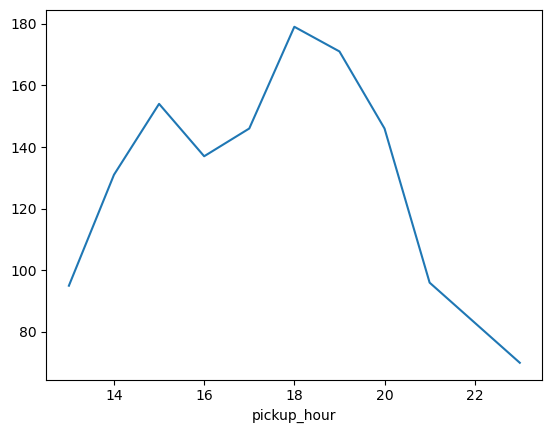

In [89]:
How does demand change across the day?
df.groupby("pickup_hour").size().plot()

In [90]:
#What is the fare efficiency (fare per mile)?
df["fare_per_mile"].describe()

count    1408.000000
mean        3.490153
std         2.031433
min         0.098333
25%         2.562012
50%         2.845624
75%         4.003282
max        25.280899
Name: fare_per_mile, dtype: float64

In [91]:
#1. How does taxi demand change throughout the day and across different days of the week?

#Goal: Identify temporal demand patterns.

df.groupby(["day_of_week","pickup_hour"]).size().unstack()

pickup_hour,13,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,
Sunday,95,131,154,137,146,179,171,146,96,83,70


In [92]:
#What percentage of total revenue comes from the top 10% highest-fare trips?

#Goal: Understand revenue concentration.
#Insight: Shows whether revenue depends heavily on premium trips.
top10 = df[df["fare"] >= df["fare"].quantile(0.90)]

top10["fare"].sum() / df["fare"].sum() * 100

np.float64(19.421131649537664)

In [93]:
#3. Do longer trips generate proportionally higher fares or is there diminishing return per mile?

#Goal: Study fare efficiency.

df["fare_per_mile"] = df["fare"] / df["trp_mi"]

df.groupby("trip_category")["fare_per_mile"].mean()

#Insight: Detect pricing inconsistencies.

trip_category
long      2.591255
medium    3.549064
short     6.465712
Name: fare_per_mile, dtype: float64

In [94]:
#4. How does average taxi speed vary by hour of the day?

#Goal: Detect traffic congestion patterns.

df.groupby("pickup_hour")["speed_mph"].mean()

#Insight: Identify rush-hour traffic effects.

pickup_hour
13    24.652345
14    23.194769
15    21.854891
16    20.181585
17    22.824123
18    23.296309
19    23.438091
20    25.658033
21    24.910388
22    26.230860
23    21.817751
Name: speed_mph, dtype: float64

In [95]:
#5. Which pickup-dropoff routes generate the highest revenue?

#Goal: Identify profitable routes.

df.groupby(["p_lat","p_lon","d_lat","d_lon"])["fare"].sum().sort_values(ascending=False).head(10)

#Insight: Useful for ride optimization strategies.

p_lat      p_lon       d_lat      d_lon     
41.980264  -87.913625  41.944227  -87.655998    1632.152438
                       41.922686  -87.649489    1441.859753
                       41.901207  -87.676356     922.902438
                       41.922761  -87.699155     820.902438
                       41.947792  -87.683835     647.957315
                       41.899602  -87.633308     538.902438
41.979071  -87.903040  41.893216  -87.637844     419.250000
41.980264  -87.913625  41.965812  -87.655879     387.500000
41.979071  -87.903040  41.884987  -87.620993     380.250000
                       41.892508  -87.626215     372.652438
Name: fare, dtype: float64

In [96]:
#6. What trips fall into the top 5% of duration and distance?

#Goal: Identify extreme trips.

df[df["trp_sec"] > df["trp_sec"].quantile(0.95)]

#Insight: Helps detect long-distance taxi demand.

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon,speed_mph,trip_duration_min,pickup_hour,day_of_week,month,fare_per_mile,is_weekend,trip_category
19,7b2bfa6fc3b8fe63b2dc759c5dccd536e28a9ce8,2023-12-31 13:15:00,2023-12-31 14:45:00,5400.0,13.400000,54.000000,41.986712,-87.663416,41.980264,-87.913625,8.933333,90.0,13,Sunday,12,4.029851,True,long
37,05bdfb189228e4fd944331ee250571c492e89669,2023-12-31 13:30:00,2023-12-31 15:00:00,5400.0,11.440000,26.402438,41.808916,-87.596183,41.878866,-87.625192,7.626667,90.0,13,Sunday,12,2.307905,True,long
118,5f80a3863f81c12095273ecea232eff82bc36c92,2023-12-31 14:00:00,2023-12-31 15:00:00,3600.0,7.789097,35.000000,42.007613,-87.813781,42.001571,-87.695013,7.789097,60.0,14,Sunday,12,4.493461,True,medium
371,d817b9754da90a66d85b63acc39d6a8ee1716b28,2023-12-31 15:45:00,2023-12-31 16:45:00,3600.0,17.310000,50.500000,41.792592,-87.769615,41.965812,-87.655879,17.310000,60.0,15,Sunday,12,2.917389,True,long
929,45f8107ab174839cd19e583dc541b744498baf83,2023-12-31 19:15:00,2023-12-31 20:15:00,3600.0,11.420000,35.750000,42.001571,-87.695013,41.899602,-87.633308,11.420000,60.0,19,Sunday,12,3.130473,True,long
947,098da8f9e21993eeceb76348bb07d22f6303aa91,2023-12-31 19:30:00,2023-12-31 20:30:00,3600.0,7.789097,41.750000,41.761578,-87.572782,41.777196,-87.642498,7.789097,60.0,19,Sunday,12,5.360057,True,medium
1069,4398236aef2072b3937fcf0fa7ace3eb915a4e5e,2023-12-31 20:15:00,2024-01-01 15:15:00,68400.0,300.000000,29.500000,41.986712,-87.663416,41.985015,-87.804532,15.789474,1140.0,20,Sunday,12,0.098333,True,long
1290,50cfd8e152db15e9cfc0b499f10b5b1bde2ca43c,2023-12-31 22:15:00,2023-12-31 23:15:00,3600.0,17.400000,61.750000,41.979071,-87.903040,41.890922,-87.618868,17.400000,60.0,22,Sunday,12,3.548851,True,long
1386,d67028d47f957f856f2ffa6209431fb6bbf970c6,2023-12-31 23:30:00,2024-01-01 01:00:00,5400.0,11.600000,49.500000,41.857184,-87.620335,41.965812,-87.655879,7.733333,90.0,23,Sunday,12,4.267241,True,long
1398,54b2e6aa52ea342d65be8a7ac93a82650e781319,2023-12-31 23:45:00,2024-01-01 00:45:00,3600.0,7.789097,26.250000,41.878866,-87.625192,41.899602,-87.633308,7.789097,60.0,23,Sunday,12,3.370096,True,medium


In [97]:
#7. Are there anomalies where fare is unusually high relative to distance?

#Goal: Detect pricing anomalies.

df[df["fare_per_mile"] > df["fare_per_mile"].quantile(0.95)]

#Insight: Could indicate surge pricing or data errors.

,trip_id,start_ts,end_ts,trp_sec,trp_mi,fare,p_lat,p_lon,d_lat,d_lon,speed_mph,trip_duration_min,pickup_hour,day_of_week,month,fare_per_mile,is_weekend,trip_category
60,d1a12868f0612e10fe2a62018fc1224858139ebc,2023-12-31 13:45:00,2023-12-31 14:00:00,900.0,1.460000,9.000000,41.944227,-87.655998,41.965812,-87.655879,5.840000,15.0,13,Sunday,12,6.164384,True,short
82,f4d2e569400bf0530674f90b7c2b1b402bf5e1db,2023-12-31 13:45:00,2023-12-31 14:00:00,900.0,1.290000,11.150000,41.902788,-87.626146,41.884987,-87.620993,5.160000,15.0,13,Sunday,12,8.643411,True,short
108,8b392519df21b6ed269746e8092bf7e099cc2f30,2023-12-31 14:00:00,2023-12-31 14:30:00,1800.0,7.789097,49.500000,41.980264,-87.913625,41.850266,-87.667569,15.578193,30.0,14,Sunday,12,6.355037,True,medium
122,a8628681b2e5fa9ae5ebf05b8c786226ee64daed,2023-12-31 14:00:00,2023-12-31 14:15:00,900.0,1.290000,9.000000,41.899156,-87.626211,41.884987,-87.620993,5.160000,15.0,14,Sunday,12,6.976744,True,short
136,2f1fd0ba93c369d44007f0bf66553a3e8b7adef3,2023-12-31 14:00:00,2023-12-31 14:15:00,900.0,1.380000,9.000000,41.899602,-87.633308,41.878866,-87.625192,5.520000,15.0,14,Sunday,12,6.521739,True,short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357,8abb5474fc45860f535538b030e49fff737f7363,2023-12-31 23:00:00,2023-12-31 23:15:00,900.0,1.440000,9.750000,41.878866,-87.625192,41.899602,-87.633308,5.760000,15.0,23,Sunday,12,6.770833,True,short
1368,0de9bf9bfea7f9a1ade28e4e2956be390abdc524,2023-12-31 23:15:00,2023-12-31 23:45:00,1800.0,3.700000,27.000000,41.899602,-87.633308,41.874005,-87.663518,7.400000,30.0,23,Sunday,12,7.297297,True,medium
1377,54846bcfa73b6da911f4acb780592ef899bbd1e4,2023-12-31 23:30:00,2023-12-31 23:45:00,900.0,1.920000,12.080000,41.857184,-87.620335,41.878866,-87.625192,7.680000,15.0,23,Sunday,12,6.291667,True,short
1391,25673a4d3eec252bdb482b4460411e7b7f7f3af3,2023-12-31 23:30:00,2023-12-31 23:45:00,900.0,3.600000,26.402438,41.899602,-87.633308,41.878866,-87.625192,14.400000,15.0,23,Sunday,12,7.334011,True,medium


In [98]:
#8. How does taxi demand evolve over time (time series analysis)?
#Goal: Study demand trends across the day.

df.groupby(df["start_ts"].dt.hour).size()

#Insight: Understand daily travel patterns.

start_ts
13     95
14    131
15    154
16    137
17    146
18    179
19    171
20    146
21     96
22     83
23     70
dtype: int64

In [99]:
#9. What locations act as major taxi hubs?

#Goal: Identify high-demand zones.

df.groupby(["p_lat","p_lon"]).size().sort_values(ascending=False).head(10)

#Insight: Helps with driver positioning strategies.

p_lat      p_lon     
41.980264  -87.913625    281
41.899602  -87.633308    166
41.979071  -87.903040     96
41.878866  -87.625192     94
41.874005  -87.663518     61
41.944227  -87.655998     54
41.792592  -87.769615     41
41.922686  -87.649489     33
41.884987  -87.620993     31
41.892508  -87.626215     31
dtype: int64

In [100]:
#10. What is the relationship between trip duration, distance, and fare?

#Goal: Understand key drivers of revenue.

df[["trp_sec","trp_mi","fare"]].corr()

#Insight: Reveals important predictive features for ML models.

,trp_sec,trp_mi,fare
trp_sec,1.000000,0.874786,0.203171
trp_mi,0.874786,1.000000,0.521076
fare,0.203171,0.521076,1.000000


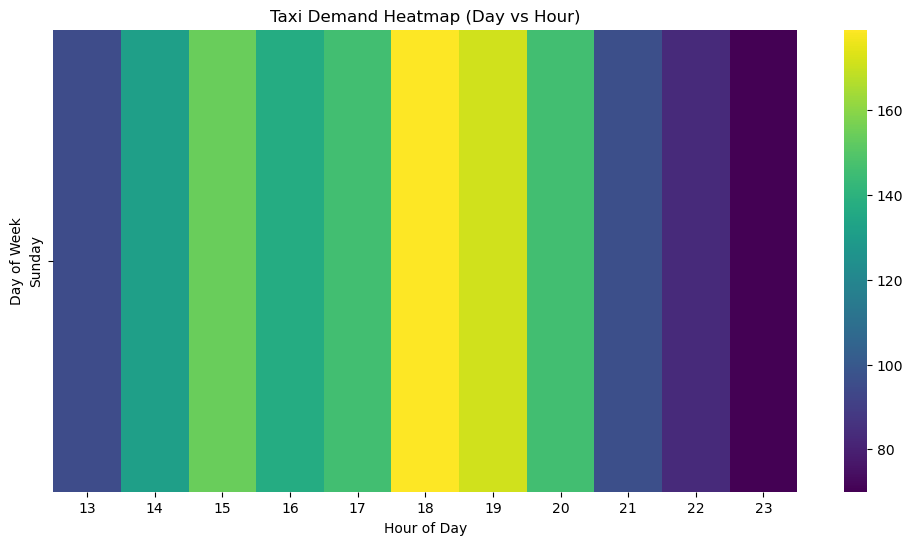

In [101]:
#Question: When is taxi demand highest?
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.pivot_table(
    index="day_of_week",
    columns="pickup_hour",
    values="trip_id",
    aggfunc="count"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="viridis")

plt.title("Taxi Demand Heatmap (Day vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

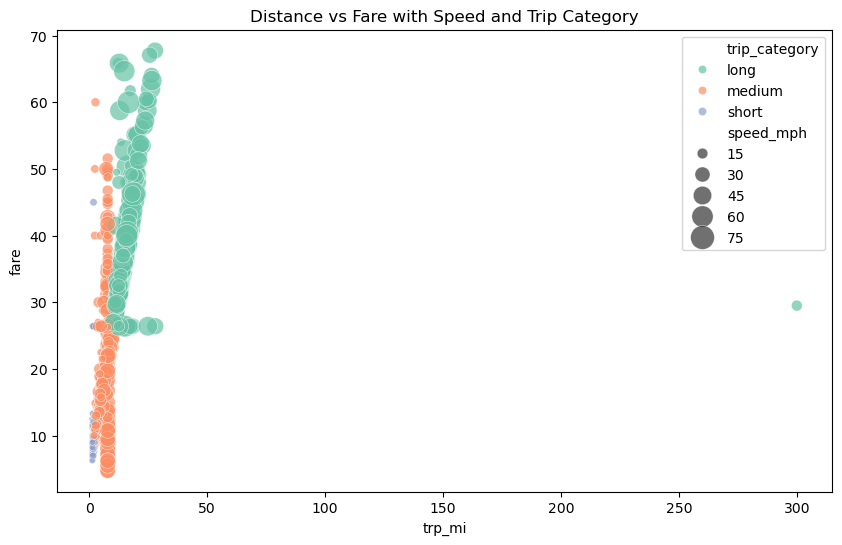

In [102]:
#How do distance, fare, and speed relate?

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="trp_mi",
    y="fare",
    hue="trip_category",
    size="speed_mph",
    sizes=(20,300),
    palette="Set2",
    alpha=0.7
)

plt.title("Distance vs Fare with Speed and Trip Category")

plt.show()

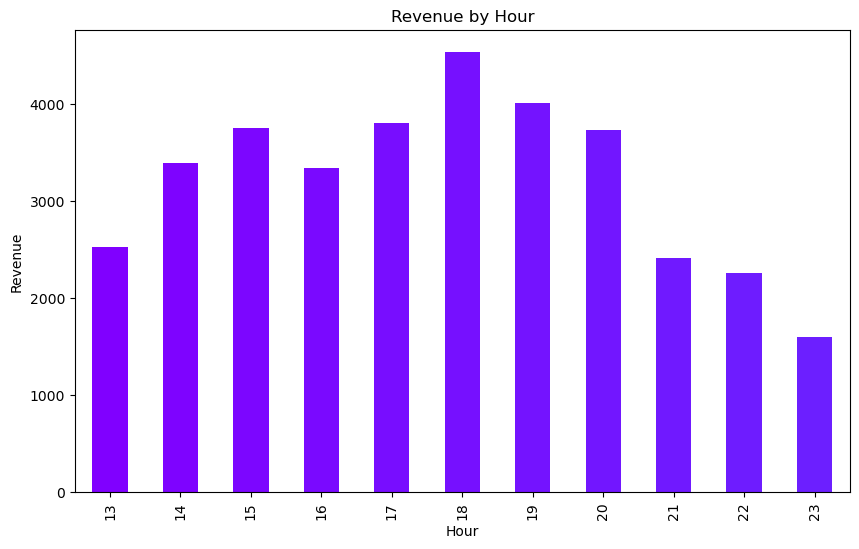

In [103]:
#Which hours generate the most revenue?

revenue = df.groupby("pickup_hour")["fare"].sum()

plt.figure(figsize=(10,6))

revenue.plot(
    kind="bar",
    color=plt.cm.rainbow(range(len(revenue)))
)

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.show()

/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_53390/170233835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


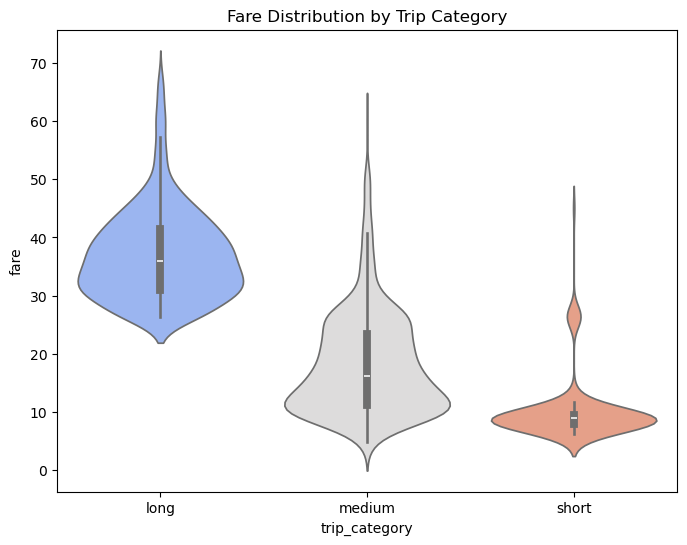

In [104]:
#How do fares vary across trip categories?

plt.figure(figsize=(8,6))

sns.violinplot(
    x="trip_category",
    y="fare",
    data=df,
    palette="coolwarm"
)

plt.title("Fare Distribution by Trip Category")

plt.show()

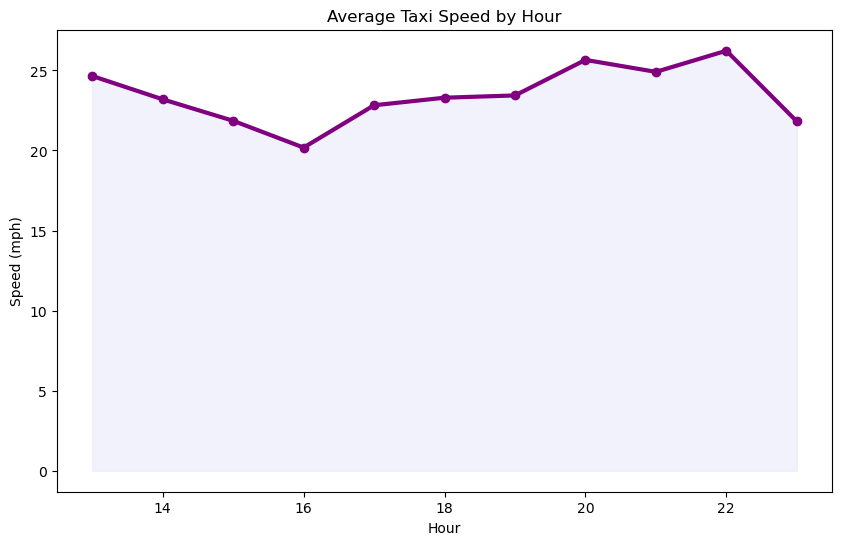

In [105]:
#When is traffic slowest?
speed = df.groupby("pickup_hour")["speed_mph"].mean()

plt.figure(figsize=(10,6))

plt.plot(
    speed.index,
    speed.values,
    marker="o",
    linewidth=3,
    color="purple"
)

plt.fill_between(
    speed.index,
    speed.values,
    color="lavender",
    alpha=0.5
)

plt.title("Average Taxi Speed by Hour")
plt.xlabel("Hour")
plt.ylabel("Speed (mph)")

plt.show()

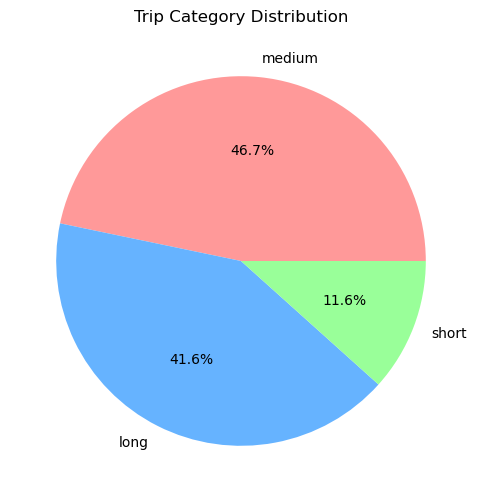

In [106]:
#What types of trips dominate?

df["trip_category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#ff9999","#66b3ff","#99ff99"],
    figsize=(6,6)
)

plt.title("Trip Category Distribution")
plt.ylabel("")

plt.show()

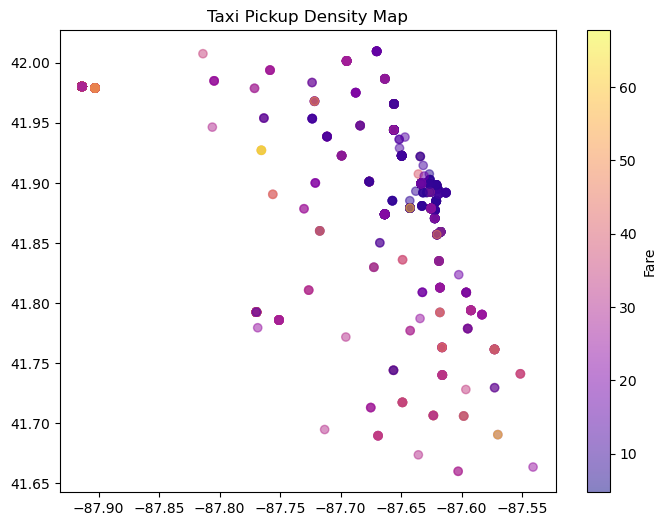

In [107]:
#Where are taxi hotspots?

plt.figure(figsize=(8,6))

plt.scatter(
    df["p_lon"],
    df["p_lat"],
    c=df["fare"],
    cmap="plasma",
    alpha=0.5
)

plt.colorbar(label="Fare")

plt.title("Taxi Pickup Density Map")

plt.show()

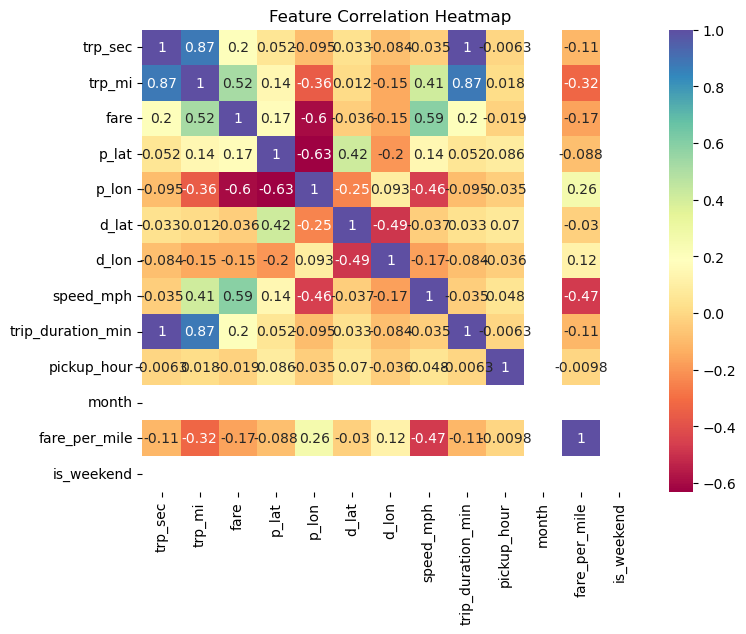

In [108]:
#What factors affect taxi fare?

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Spectral"
)

plt.title("Feature Correlation Heatmap")

plt.show()

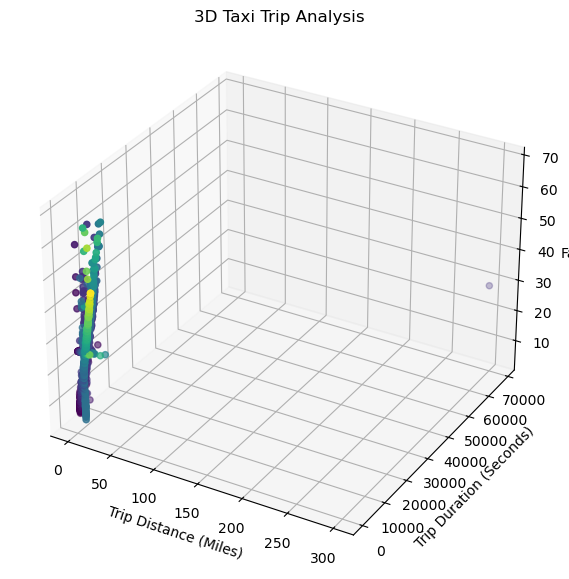

In [109]:
#How do distance, duration, and fare interact together?
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["trp_mi"],
    df["trp_sec"],
    df["fare"],
    c=df["speed_mph"],
    cmap="viridis"
)

ax.set_xlabel("Trip Distance (Miles)")
ax.set_ylabel("Trip Duration (Seconds)")
ax.set_zlabel("Fare")

plt.title("3D Taxi Trip Analysis")

plt.show()

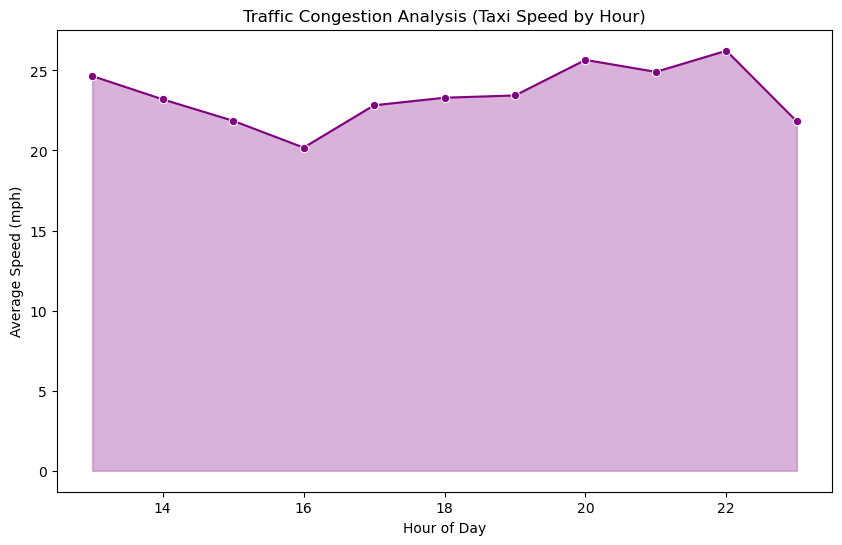

In [110]:
#When does traffic slow taxis the most?
import seaborn as sns
import matplotlib.pyplot as plt

speed_hour = df.groupby("pickup_hour")["speed_mph"].mean()

plt.figure(figsize=(10,6))

sns.lineplot(
    x=speed_hour.index,
    y=speed_hour.values,
    marker="o",
    color="purple"
)

plt.fill_between(
    speed_hour.index,
    speed_hour.values,
    alpha=0.3,
    color="purple"
)

plt.title("Traffic Congestion Analysis (Taxi Speed by Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Speed (mph)")

plt.show()

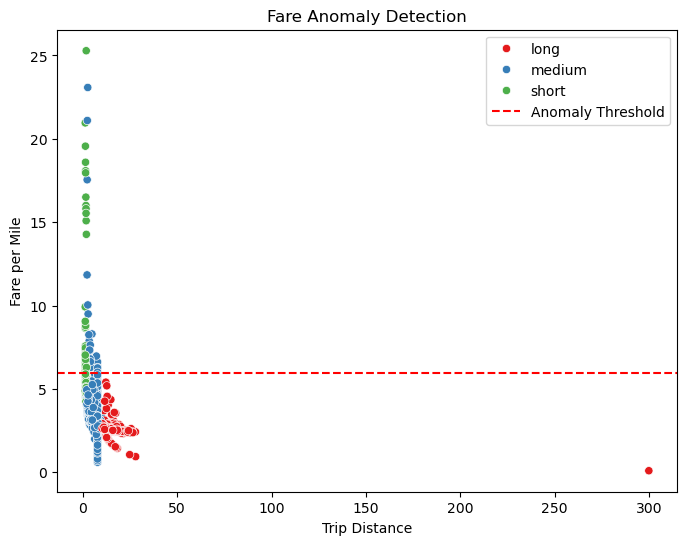

In [112]:
#Are some trips overpriced compared to distance?

#First calculate fare per mile.
df["fare_per_mile"] = df["fare"] / df["trp_mi"]

#Then visualize anomalies.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="trp_mi",
    y="fare_per_mile",
    data=df,
    hue="trip_category",
    palette="Set1"
)

plt.axhline(
    df["fare_per_mile"].quantile(0.95),
    color="red",
    linestyle="--",
    label="Anomaly Threshold"
)

plt.title("Fare Anomaly Detection")

plt.xlabel("Trip Distance")
plt.ylabel("Fare per Mile")

plt.legend()

plt.show()



NameError: name 'demand' is not defined

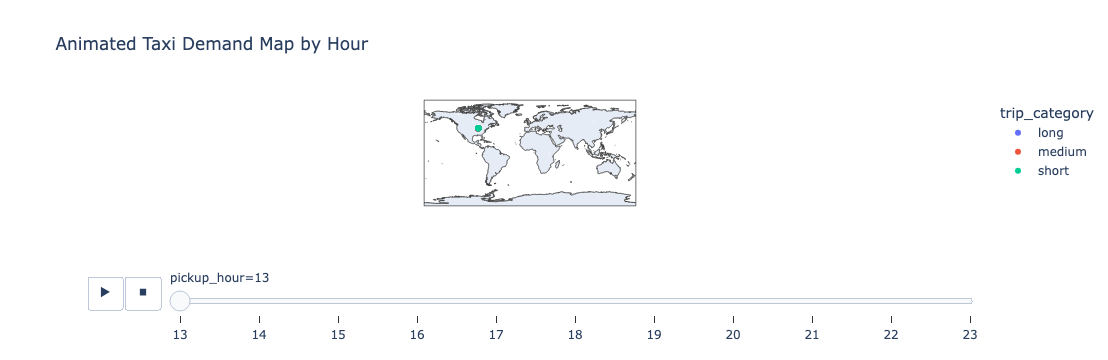

In [115]:
#How does taxi demand move across the city during the day?
df["pickup_hour"] = df["start_ts"].dt.hour
import plotly.express as px

fig = px.scatter_geo(
    df,
    lat="p_lat",
    lon="p_lon",
    color="trip_category",
    animation_frame="pickup_hour",
    title="Animated Taxi Demand Map by Hour"
)

fig.show()


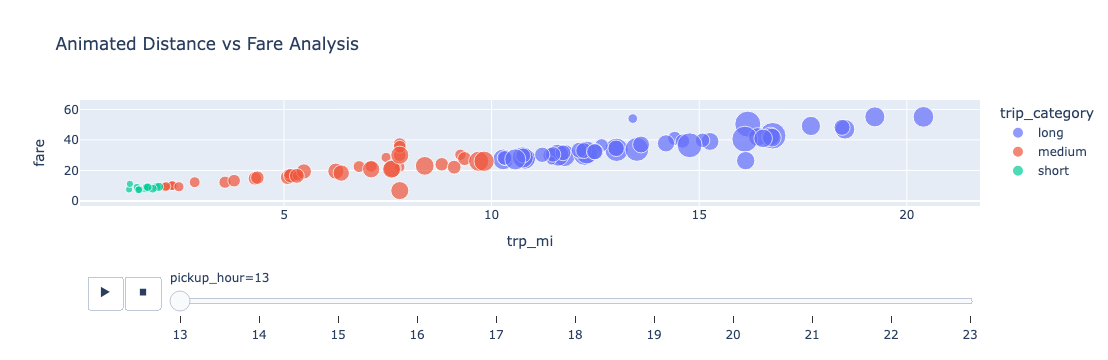

In [116]:
#How do trip patterns change over time?
fig = px.scatter(
    df,
    x="trp_mi",
    y="fare",
    size="speed_mph",
    color="trip_category",
    animation_frame="pickup_hour",
    title="Animated Distance vs Fare Analysis"
)

fig.show()

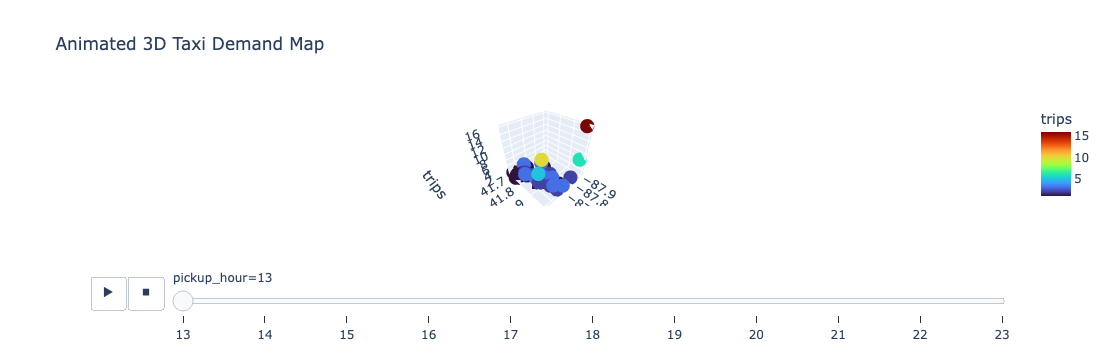

In [117]:
#How does taxi demand move across the city over time?
import pandas as pd

df["pickup_hour"] = df["start_ts"].dt.hour

demand_map = df.groupby(
    ["pickup_hour","p_lat","p_lon"]
).size().reset_index(name="trips")
import plotly.express as px

fig = px.scatter_3d(
    demand_map,
    x="p_lon",
    y="p_lat",
    z="trips",
    color="trips",
    animation_frame="pickup_hour",
    color_continuous_scale="Turbo",
    title="Animated 3D Taxi Demand Map"
)

fig.show()